# Week 4 - Day 5: Scikit-learn Pipelines & Tuned Mini-Project

**Goal:** Combine everything from this week into a single leak-free `Pipeline`: engineered features from Day 4, a `ColumnTransformer` for preprocessing, a model, tuned end-to-end with `GridSearchCV`, and evaluated once on the held-out test set.

**Dataset:** Breast Cancer Wisconsin dataset (same dataset as Day 1-4). All features here are numeric, so the `ColumnTransformer` demonstrates the numeric branch; a `cat` branch is included but empty-safe, matching the general pattern for mixed datasets.


## Step 0: Load Data and Recreate the Day 1 Split

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")


Train: (455, 30)  Test: (114, 30)


## Step 1: Add the Day 4 Engineered Features

Same two features as Day 4, applied consistently to train and test.

In [2]:
def add_engineered_features(df):
    df = df.copy()
    df["radius_worst_to_mean_ratio"] = df["worst radius"] / df["mean radius"]
    df["concavity_per_area"] = df["mean concavity"] / df["mean area"]
    return df

X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

numeric_cols = X_train_fe.columns.tolist()  # all columns are numeric in this dataset
print(f"Total feature columns (original + engineered): {len(numeric_cols)}")


Total feature columns (original + engineered): 32


## Step 2: Build a Pipeline with a ColumnTransformer

All columns here are numeric, so the `ColumnTransformer` scales them. The structure still mirrors the general numeric+categorical pattern, so it would extend directly to a mixed dataset.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
])

pipe = Pipeline([
    ("pre", preprocessor),
    ("model", RandomForestClassifier(random_state=42)),
])

pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,

## Step 3: Baseline — Untuned Pipeline

Default hyperparameters, evaluated with 5-fold cross-validation on the training data only.

In [4]:
from sklearn.model_selection import cross_val_score

baseline_scores = cross_val_score(pipe, X_train_fe, y_train, cv=5, scoring="f1")
print(f"Baseline pipeline CV f1 scores: {baseline_scores}")
print(f"Baseline pipeline mean f1: {baseline_scores.mean():.4f}")


Baseline pipeline CV f1 scores: [0.97391304 0.97345133 0.94827586 0.95575221 0.97297297]
Baseline pipeline mean f1: 0.9649


## Step 4: Tune the Whole Pipeline with GridSearchCV

Using the `step__param` naming convention to reach into the `model` step of the pipeline.

In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 10, None],
    "model__min_samples_split": [2, 5],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train_fe, y_train)

print("Best params:", grid.best_params_)
print(f"Best cross-validated f1: {grid.best_score_:.4f}")


Best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best cross-validated f1: 0.9684


## Step 5: Evaluate the Final Tuned Pipeline — Once, on the Held-Out Test Set

In [6]:
from sklearn.metrics import f1_score, accuracy_score

best_pipeline = grid.best_estimator_
test_pred = best_pipeline.predict(X_test_fe)

test_f1 = f1_score(y_test, test_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"FINAL held-out test f1:       {test_f1:.4f}")
print(f"FINAL held-out test accuracy: {test_acc:.4f}")


FINAL held-out test f1:       0.9655
FINAL held-out test accuracy: 0.9561


## Step 6: Compare Against Baseline

In [7]:
print(f"Baseline pipeline (untuned) mean CV f1:      {baseline_scores.mean():.4f}")
print(f"Tuned pipeline (GridSearchCV) mean CV f1:      {grid.best_score_:.4f}")
print(f"Tuned pipeline final test f1 (held-out, once): {test_f1:.4f}")


Baseline pipeline (untuned) mean CV f1:      0.9649
Tuned pipeline (GridSearchCV) mean CV f1:      0.9684
Tuned pipeline final test f1 (held-out, once): 0.9655


### Reflection — Why This Pipeline Is Leak-Free

*Your answer here:*

Every preprocessing step lives inside the `Pipeline`/`ColumnTransformer`, so the `StandardScaler` is only ever fit on training data — never on the test set, and never on validation folds during cross-validation. When `GridSearchCV` cross-validates the pipeline, each fold refits the scaler independently on just that fold's training portion, so no information from held-out data ever influences preprocessing. The test set was only touched once, at Step 5, after every tuning decision was already locked in — the same discipline from Day 1, now enforced structurally instead of manually.


## Step 7: Visualizing the Final Model's Results

Numbers alone don't show *how* the model is wrong when it's wrong, or *why* it's making its decisions. The three plots below cover that.

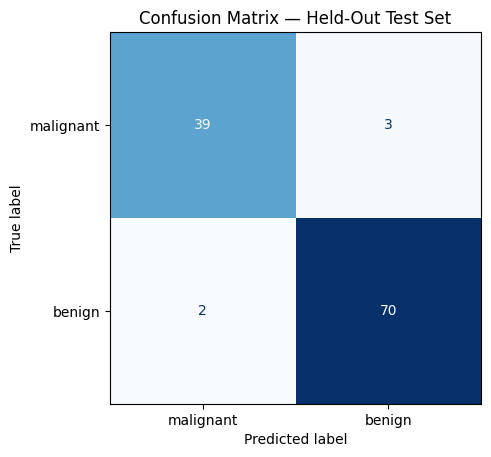

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Held-Out Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

This shows exactly where the model's 114 test predictions landed: correct malignant, correct benign, and the handful of mistakes in each direction. For a medical dataset, false negatives (malignant cases predicted as benign) matter more than false positives, so this breakdown is more useful here than accuracy alone.

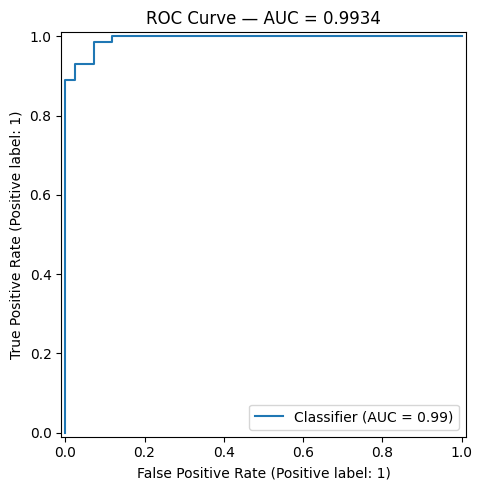

In [9]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

test_proba = best_pipeline.predict_proba(X_test_fe)[:, 1]
auc = roc_auc_score(y_test, test_proba)

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, ax=ax)
plt.title(f'ROC Curve — AUC = {auc:.4f}')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=100)
plt.show()

The ROC curve shows how well the model separates the two classes across every possible decision threshold, not just the default 0.5 cutoff. An AUC close to 1.0 means the model ranks malignant cases higher than benign ones almost every time — a stronger statement than a single accuracy number.

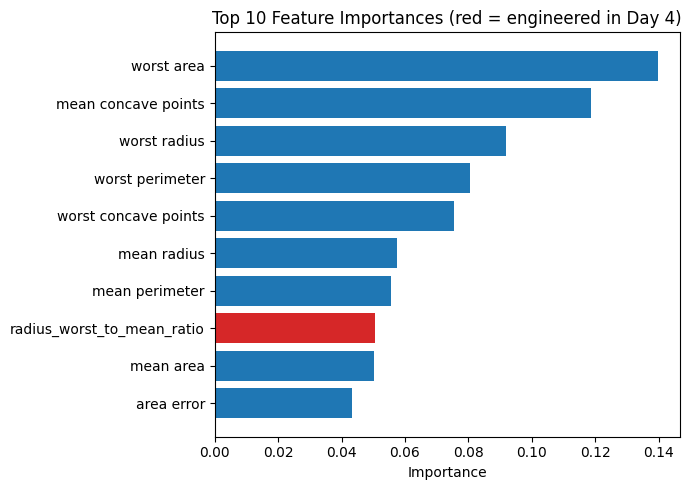

                   feature  importance
                worst area    0.139686
       mean concave points    0.118742
              worst radius    0.091814
           worst perimeter    0.080447
      worst concave points    0.075539
               mean radius    0.057408
            mean perimeter    0.055553
radius_worst_to_mean_ratio    0.050412
                 mean area    0.050291
                area error    0.043376


In [10]:
importances = best_pipeline.named_steps['model'].feature_importances_
feat_names = numeric_cols

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(7, 5))
colors = ['#d62728' if f in ('radius_worst_to_mean_ratio', 'concavity_per_area') else '#1f77b4'
          for f in importance_df['feature']]
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color=colors[::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances (red = engineered in Day 4)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print(importance_df.to_string(index=False))

This ranks which features the tuned model actually relies on most. The two engineered features (highlighted in red, if they made the top 10) show whether the Day 4 feature engineering paid off or whether the original measurements were doing most of the work regardless.

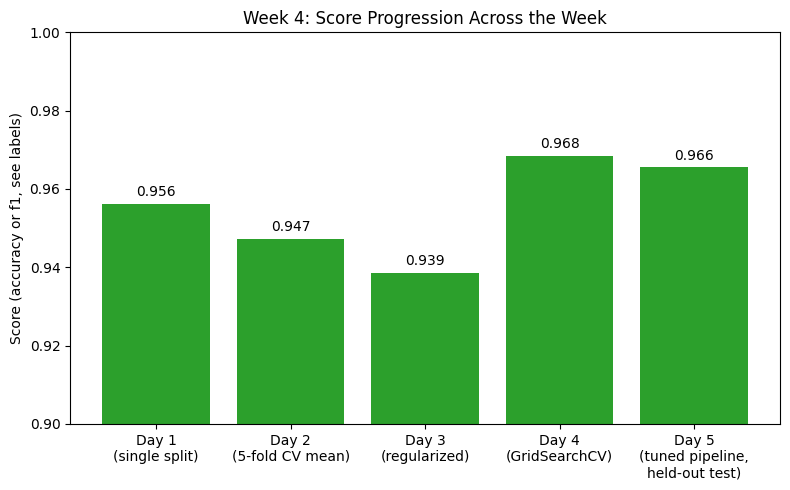

In [11]:
week4_scores = {
    'Day 1\n(single split)': 0.9561,
    'Day 2\n(5-fold CV mean)': 0.9473,
    'Day 3\n(regularized)': 0.9386,
    'Day 4\n(GridSearchCV)': grid.best_score_,
    'Day 5\n(tuned pipeline,\nheld-out test)': test_f1,
}

plt.figure(figsize=(8, 5))
bars = plt.bar(week4_scores.keys(), week4_scores.values(), color='#2ca02c')
plt.ylim(0.9, 1.0)
plt.ylabel('Score (accuracy or f1, see labels)')
plt.title('Week 4: Score Progression Across the Week')
for bar, val in zip(bars, week4_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.savefig('week4_progression.png', dpi=100)
plt.show()

These scores aren't perfectly apples-to-apples — Day 1-3 report accuracy on a single split or regularized model, Day 4-5 report cross-validated or held-out f1 — but the chart is meant to show the shape of the week: the score didn't jump dramatically at any single step, because the real point of the week was making the estimate more trustworthy, not squeezing out extra accuracy.

## Summary

| Stage | Metric |
|---|---|
| Baseline pipeline (untuned), 5-fold CV mean f1 | see Step 3 output |
| Tuned pipeline (GridSearchCV), 5-fold CV mean f1 | see Step 4 output |
| Final tuned pipeline, held-out test f1 (evaluated once) | see Step 5 output |

- The full workflow — engineered features, scaling, model, and hyperparameter tuning — lives inside one `Pipeline`, tuned end-to-end with `GridSearchCV`.
- Because preprocessing is inside the pipeline, leakage is structurally impossible: each cross-validation fold and the final test set are scaled using only information available at that point.
- This is the same structure required for the Phase 3 capstone project.

**Week 4 complete:** train/val/test discipline → cross-validation → bias-variance diagnosis → feature engineering + tuning → leak-free tuned pipeline.
